# Polynomial Interpolation Playground
This notebook lets you:
- Visualize Lagrange, Newton, and Hermite interpolants against various test functions.
- Experiment with how the number and placement of nodes affect accuracy and oscillations.
- Compare error curves (log scale) for the three methods as node count grows.

Run the simulation cell to see overlayed interpolants; run the error-vs-nodes cell to view convergence behavior. Adjust node counts, step `h` for Hermite derivatives, or swap functions to explore different smoothness/curvature scenarios.


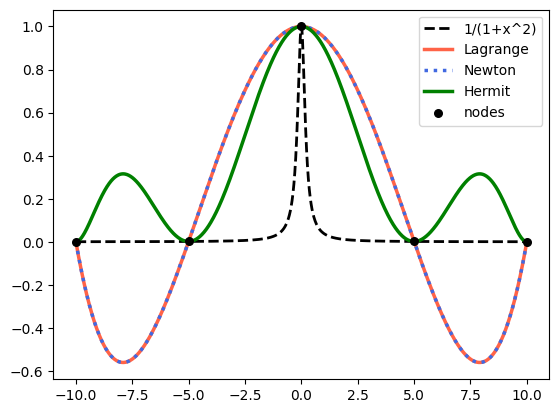

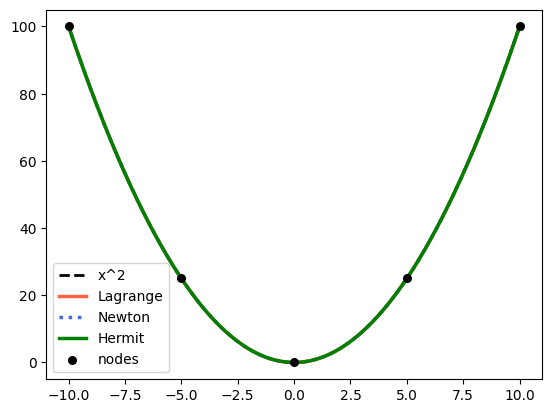

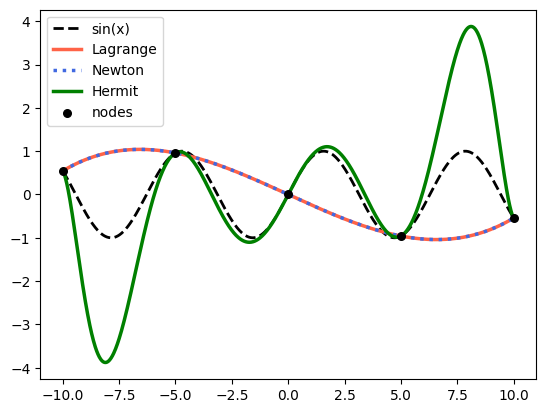

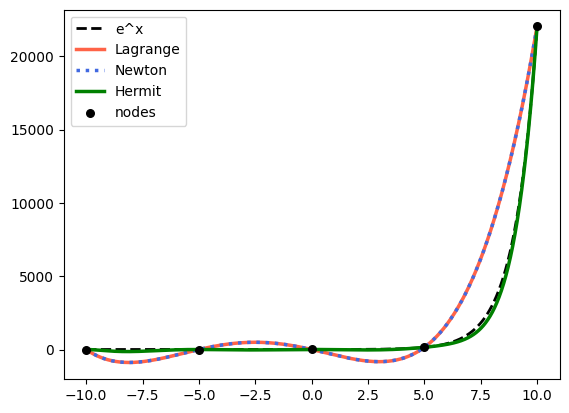

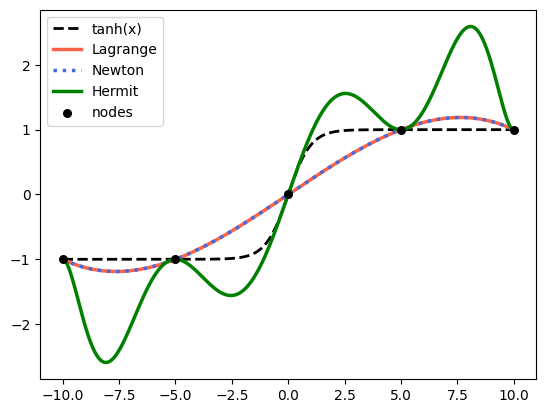

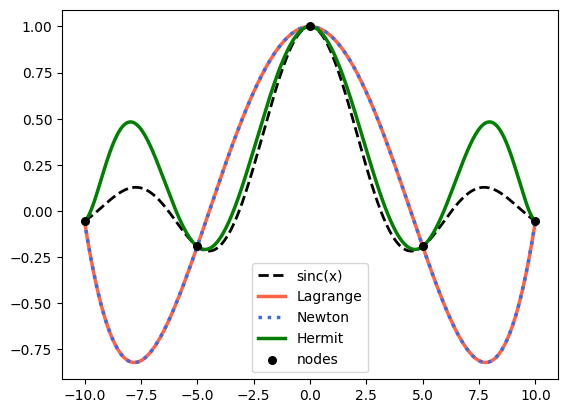

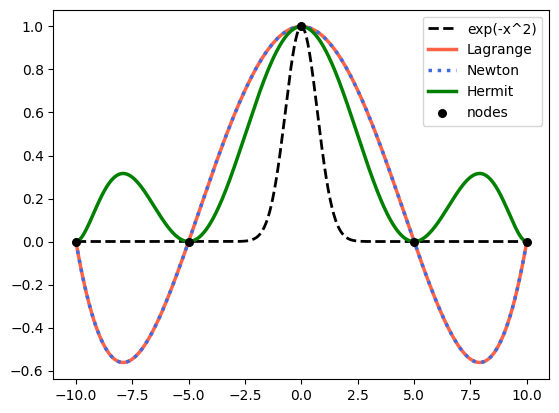

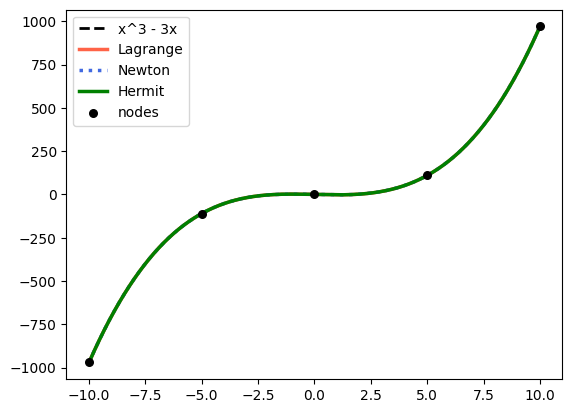

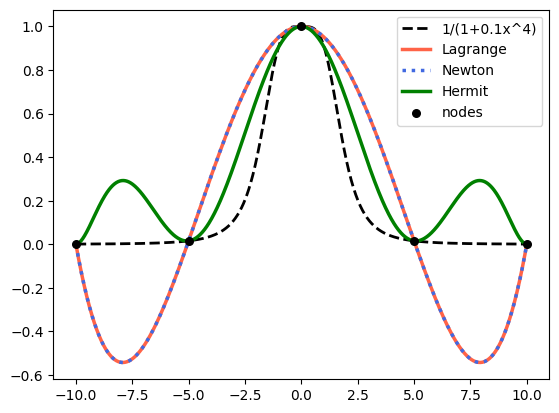

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("/Users/I768838/Desktop/Probabilistic-quadrature")))

import numpy as np
import matplotlib.pyplot as plt

from source.functions.function import Function
from source.functions.domain import Domain
from source.functions.interval import Interval
from source.functions.polynomial_interpolations.interpolation_pattern import InterpolationPattern
from source.functions.polynomial_interpolations.polynomial_interpolation_factory.polynomial_interpolation_factory import PolynomialInterpolationFactory


def plot_function(function, left, right, point_density, *, label, color, ls="-", lw=2):
    xs = np.linspace(left, right, point_density)
    ys = [function(x) for x in xs]
    plt.plot(xs, ys, label=label, color=color, linestyle=ls, linewidth=lw)


def simulation(function_predicate, function_representation):
    function = Function(function_predicate, Domain(Interval(float("-inf"), float("inf"))), None, function_representation)
    factory = PolynomialInterpolationFactory()

    nodes = list(np.linspace(-10, 10, 5))
    values = [function(x) for x in nodes]

    lagrange_poly = factory.create(InterpolationPattern.LAGRANGE, nodes, values)
    newton_poly = factory.create(InterpolationPattern.NEWTON, nodes, values)
    hermit_poly = factory.create(InterpolationPattern.HERMIT, nodes, values, function, 0.0001)

    plot_function(function, -10, 10, 1000, label=function_representation, color="black", ls="--", lw=2)
    plot_function(lagrange_poly, -10, 10, 1000, label="Lagrange", color="tomato", ls="-", lw=2.5)
    plot_function(newton_poly, -10, 10, 1000, label="Newton", color="royalblue", ls=":", lw=2.5)
    plot_function(hermit_poly, -10, 10, 1000, label="Hermit", color="green", lw=2.5)
    plt.scatter(nodes, values, color="black", s=30, zorder=3, label="nodes")
    plt.legend()
    plt.show()


simulation(lambda x: 1 / (1 + 25 * (x ** 2)), "1/(1+x^2)")
simulation(lambda x: x ** 2, "x^2")
simulation(lambda x: np.sin(x), "sin(x)")
simulation(lambda x: np.exp(x), "e^x")
simulation(lambda x: np.tanh(x), "tanh(x)")
simulation(lambda x: np.sinc(x/np.pi), "sinc(x)")
simulation(lambda x: np.exp(-x**2), "exp(-x^2)")
simulation(lambda x: x**3 - 3*x, "x^3 - 3x")
simulation(lambda x: 1 / (1 + 0.1 * x**4), "1/(1+0.1x^4)")

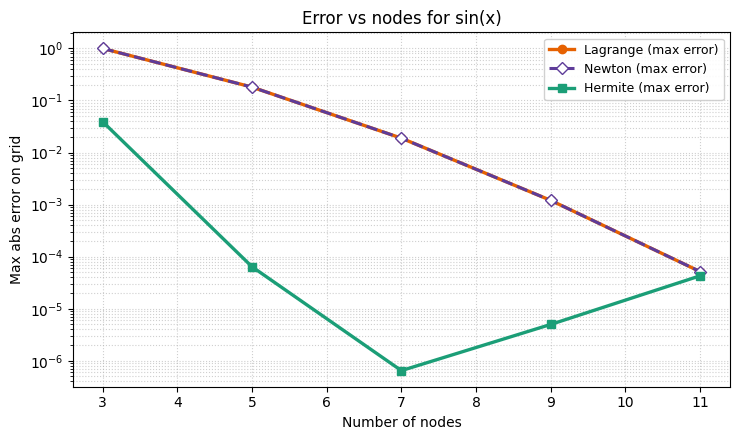

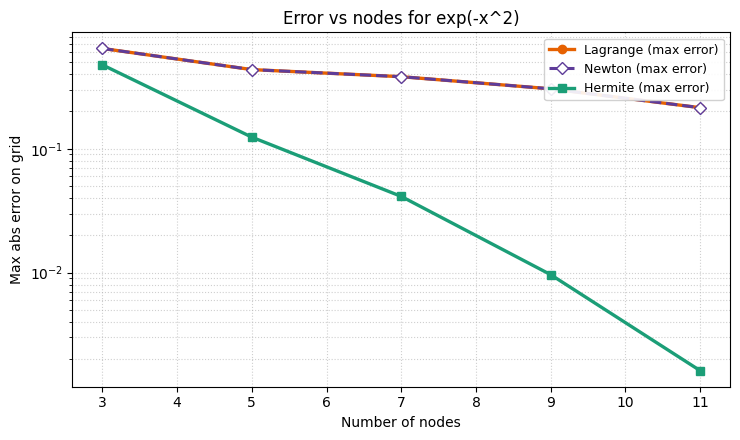

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from source.functions.function import Function
from source.functions.domain import Domain
from source.functions.interval import Interval
from source.functions.polynomial_interpolations.interpolation_pattern import InterpolationPattern
from source.functions.polynomial_interpolations.polynomial_interpolation_factory.polynomial_interpolation_factory import PolynomialInterpolationFactory


def error_vs_nodes(func, label, node_counts, left, right, h=1e-3):
    grid = np.linspace(left, right, 1000)
    fobj = Function(func, Domain(Interval(left - h, right + h)), None, label)
    factory = PolynomialInterpolationFactory()
    true_vals = np.array([fobj(x) for x in grid])
    lag_errs, newton_errs, herm_errs = [], [], []

    for n in node_counts:
        nodes = np.linspace(left, right, n)
        values = [fobj(x) for x in nodes]
        lag_poly = factory.create(InterpolationPattern.LAGRANGE, nodes, values)
        newton_poly = factory.create(InterpolationPattern.NEWTON, nodes, values)
        herm_poly = factory.create(InterpolationPattern.HERMIT, nodes, values, fobj, h)

        lag_errs.append(np.max(np.abs(true_vals - np.array([lag_poly(x) for x in grid]))))
        newton_errs.append(np.max(np.abs(true_vals - np.array([newton_poly(x) for x in grid]))))
        herm_errs.append(np.max(np.abs(true_vals - np.array([herm_poly(x) for x in grid]))))

    plt.figure(figsize=(7.5, 4.5))
    plt.plot(node_counts, lag_errs, marker='o', markersize=6, linewidth=2.4, color='#e66101', label='Lagrange (max error)')
    plt.plot(node_counts, newton_errs, marker='D', markersize=6, linewidth=2.2, markerfacecolor='white', linestyle='--', color='#5e3c99', label='Newton (max error)')
    plt.plot(node_counts, herm_errs, marker='s', markersize=6, linewidth=2.4, color='#1b9e77', label='Hermite (max error)')
    plt.yscale('log')
    plt.xlabel('Number of nodes')
    plt.ylabel('Max abs error on grid')
    plt.title(f'Error vs nodes for {label}')
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, framealpha=0.9, fontsize=9)
    plt.tight_layout()
    plt.show()


error_vs_nodes(lambda x: np.sin(x), 'sin(x)', [3, 5, 7, 9, 11], -np.pi, np.pi)
error_vs_nodes(lambda x: np.exp(-x**2), 'exp(-x^2)', [3, 5, 7, 9, 11], -3, 3)


## Conclusion
- **Method relationships.** Lagrange and Newton generate the same polynomial for identical nodes/values; Newton differs only in the computational form. Hermite uses both values and derivatives, producing a higher-degree (2n−1) interpolant that can lower the error between nodes when derivatives are reliable.
- **Smooth / analytic functions (e.g., sin(x), exp(-x²)).** With evenly spaced nodes the max error shrinks quickly as node count grows (see error-vs-nodes plots). Hermite typically converges faster because derivative data encodes local curvature.
- **Functions with strong curvature or nearby singularities (e.g., 1/(1+25x²)).** Very high degree with equispaced nodes can trigger Runge oscillations near the ends. Improvements: (1) keep a moderate number of nodes, (2) switch to Chebyshev-like nodes, (3) use Hermite only if derivatives are accurate—derivatives alone cannot fix poor node placement.
- **Non-smooth functions (kinks, discontinuities).** Polynomial interpolation deteriorates; adding nodes may not help and can worsen oscillations. Prefer piecewise (splines) or reduce the interval.
- **Oscillatory functions.** Increasing nodes helps in the interior but may still show edge wiggles with equispaced nodes; Chebyshev spacing mitigates this. Hermite helps capture local slope but inherits the edge sensitivity.
- **Practical guidance.** For equispaced demos, 5–15 nodes are a sweet spot. If higher accuracy is needed, switch to better node distributions or lower-degree piecewise polynomials. Ensure derivative estimates (step h) keep x±h inside the domain to avoid boundary failures.
